In [16]:
import pandas as pd

df_raw = pd.read_csv("../data/wrangled_sol_data.csv")

print("Column names:")
print(df_raw.columns.tolist())

print("\nFirst 2 rows:")
print(df_raw.head(2))

print("\nData types:")
print(df_raw.dtypes)

Column names:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA_7', 'MA_21', 'Price_Range', 'Volume_Change', 'Target']

First 2 rows:
         Date     Close     High       Low      Open    Volume  Daily_Return  \
0  2020-09-21  2.782509  3.02694  2.500419  2.870903  19492894     -3.078959   
1  2020-09-22  2.915519  2.99437  2.668603  2.773688  18556523      4.780215   

       MA_7     MA_21  Price_Range  Volume_Change  Target  
0  2.880948  3.199595     0.526521     111.481720       1  
1  2.877576  3.131548     0.325767      -4.803653       0  

Data types:
Date                 str
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Daily_Return     float64
MA_7             float64
MA_21            float64
Price_Range      float64
Volume_Change    float64
Target             int64
dtype: object


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv("../data/wrangled_sol_data.csv", index_col=0, parse_dates=True)


df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns


df.columns = [str(col).strip() for col in df.columns]

print(df.shape)
df.head()

(1197, 11)


,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_21,Price_Range,Volume_Change,Target
Date,,,,,,,,,,,
2020-09-21,2.782509,3.026940,2.500419,2.870903,19492894,-3.078959,2.880948,3.199595,0.526521,111.481720,1
2020-09-22,2.915519,2.994370,2.668603,2.773688,18556523,4.780215,2.877576,3.131548,0.325767,-4.803653,0
2020-09-23,2.836757,3.065338,2.746303,2.930355,16096650,-2.701476,2.919199,3.068323,0.319035,-13.256109,1
2020-09-24,3.132715,3.251563,2.795647,2.838121,18993326,10.432971,2.953605,3.049531,0.455916,17.995521,1
2020-09-25,3.188612,3.265165,2.911772,3.145544,15935143,1.784299,2.965129,3.032523,0.353393,-16.101356,0


In [18]:
print("=== Descriptive Statistics ===\n")
print(df.describe().round(2))

=== Descriptive Statistics ===

         Close     High      Low     Open        Volume  Daily_Return  \
count  1197.00  1197.00  1197.00  1197.00  1.197000e+03       1197.00   
mean     51.20    53.54    48.80    51.14  1.199127e+09          0.53   
std      54.91    57.34    52.32    54.96  1.419874e+09          6.89   
min       1.21     1.38     1.09     1.21  6.139511e+06        -42.28   
25%      19.23    19.67    18.77    19.17  2.787295e+08         -3.20   
50%      30.39    31.93    28.55    30.39  6.968949e+08         -0.02   
75%      60.99    63.83    57.86    59.80  1.708817e+09          3.58   
max     258.93   260.06   246.12   258.78  1.706864e+10         36.19   

          MA_7    MA_21  Price_Range  Volume_Change  Target  
count  1197.00  1197.00      1197.00        1197.00  1197.0  
mean     50.95    50.40         4.73           9.95     0.5  
std      54.68    54.17         6.26          54.69     0.5  
min       1.38     1.53         0.07         -68.80     0.0  


In [12]:
print("=== Additional Statistics ===\n")
print(f"Average Daily Return     : {df['Daily_Return'].mean():.4f}%")
print(f"Max Single Day Gain      : {df['Daily_Return'].max():.4f}%")
print(f"Max Single Day Loss      : {df['Daily_Return'].min():.4f}%")
print(f"Return Std Dev (Volatility): {df['Daily_Return'].std():.4f}%")
print(f"Days Price Went UP       : {df['Target'].sum()}")
print(f"Days Price Went DOWN     : {(df['Target'] == 0).sum()}")
print(f"Target Balance (% UP)    : {df['Target'].mean()*100:.2f}%")

=== Additional Statistics ===

Average Daily Return     : 0.4485%
Max Single Day Gain      : 47.2828%
Max Single Day Loss      : -42.2809%
Return Std Dev (Volatility): 6.3821%
Days Price Went UP       : 1031.0
Days Price Went DOWN     : 1041
Target Balance (% UP)    : 49.76%


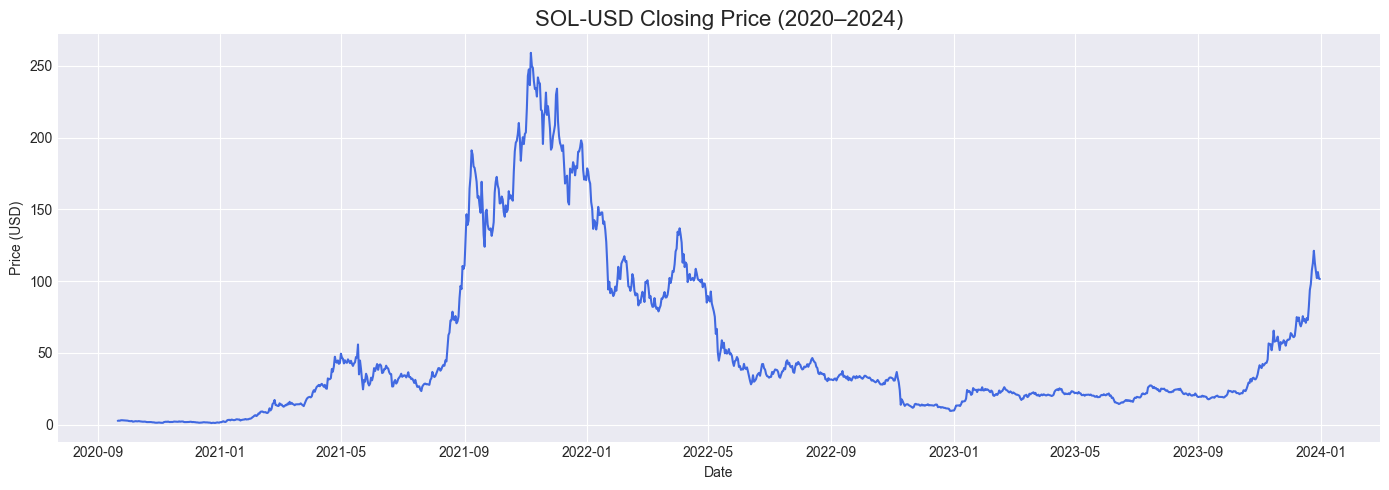

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df['Close'].values, color='royalblue', linewidth=1.5)
plt.title('SOL-USD Closing Price (2020–2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../data/sol_closing_price.png', dpi=150)
plt.show()

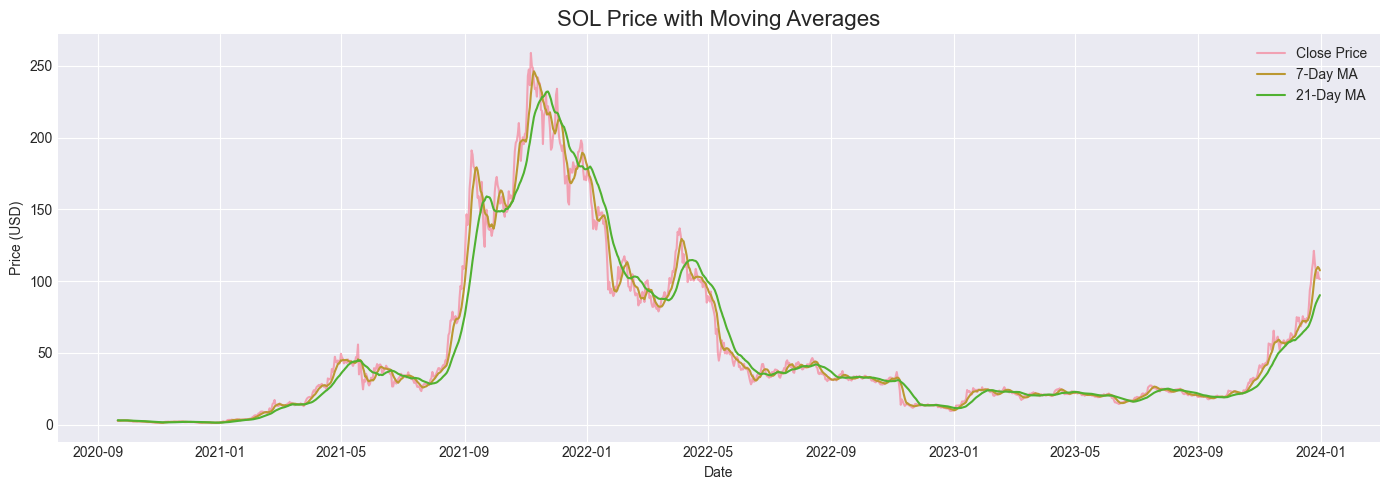

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', alpha=0.6)
plt.plot(df['MA_7'],  label='7-Day MA',   linewidth=1.5)
plt.plot(df['MA_21'], label='21-Day MA',  linewidth=1.5)
plt.title('SOL Price with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/sol_moving_averages.png', dpi=150)
plt.show()

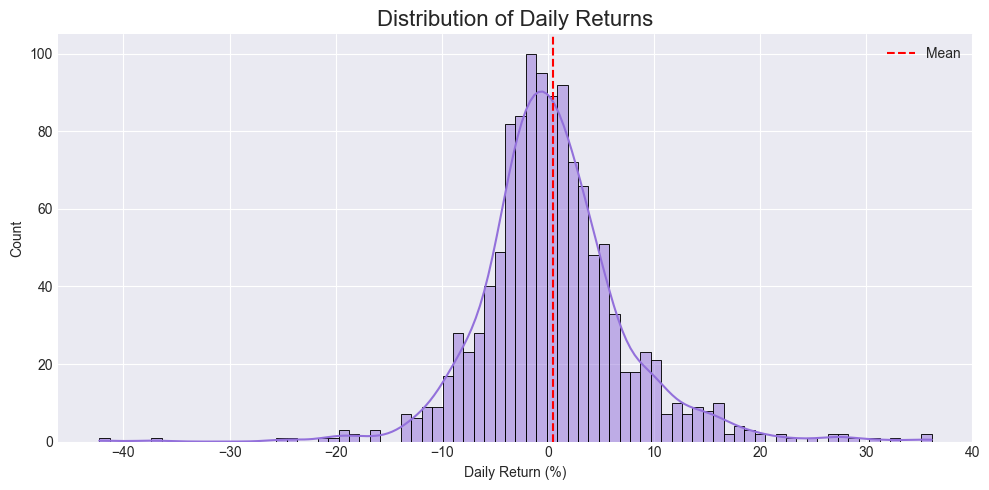

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily_Return'], bins=80, kde=True, color='mediumpurple')
plt.axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/sol_return_distribution.png', dpi=150)
plt.show()

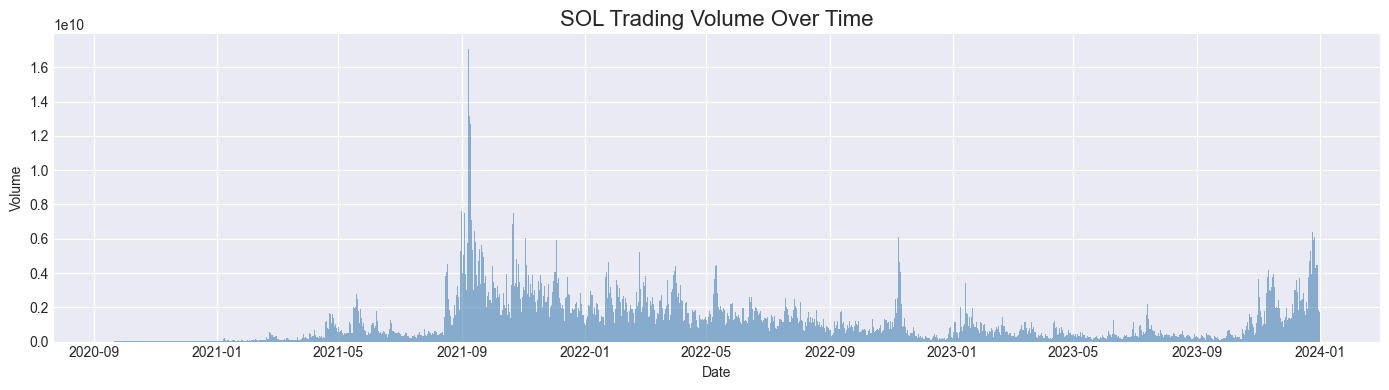

In [22]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='steelblue', alpha=0.6, width=1)
plt.title('SOL Trading Volume Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.savefig('../data/sol_volume.png', dpi=150)
plt.show()

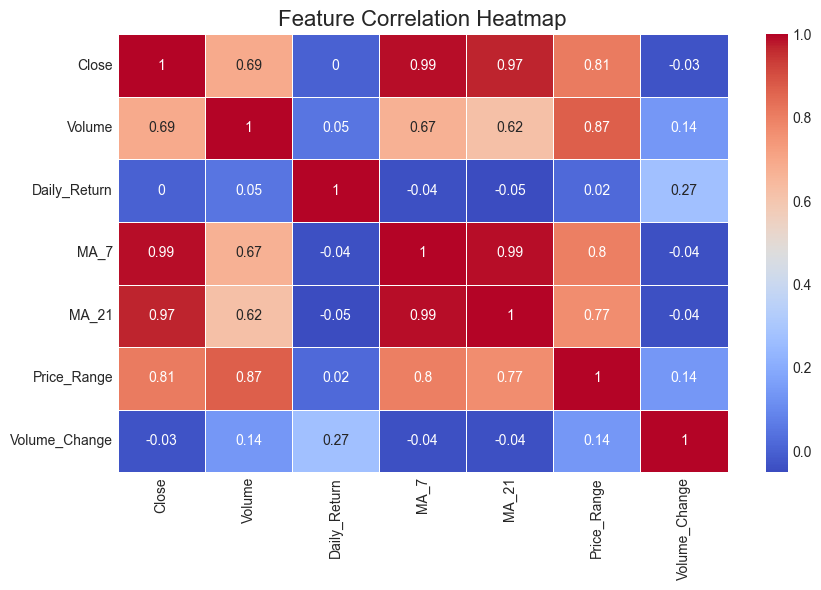

In [23]:
cols = ['Close', 'Volume', 'Daily_Return', 'MA_7', 'MA_21', 'Price_Range', 'Volume_Change']

plt.figure(figsize=(9, 6))
sns.heatmap(df[cols].corr().round(2), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../data/sol_correlation_heatmap.png', dpi=150)
plt.show()

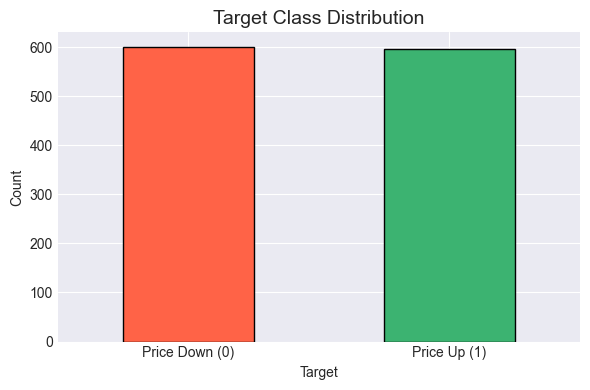

In [24]:
plt.figure(figsize=(6, 4))
df['Target'].value_counts().plot(kind='bar', color=['tomato', 'mediumseagreen'], edgecolor='black')
plt.xticks([0, 1], ['Price Down (0)', 'Price Up (1)'], rotation=0)
plt.title('Target Class Distribution', fontsize=14)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/sol_target_balance.png', dpi=150)
plt.show()

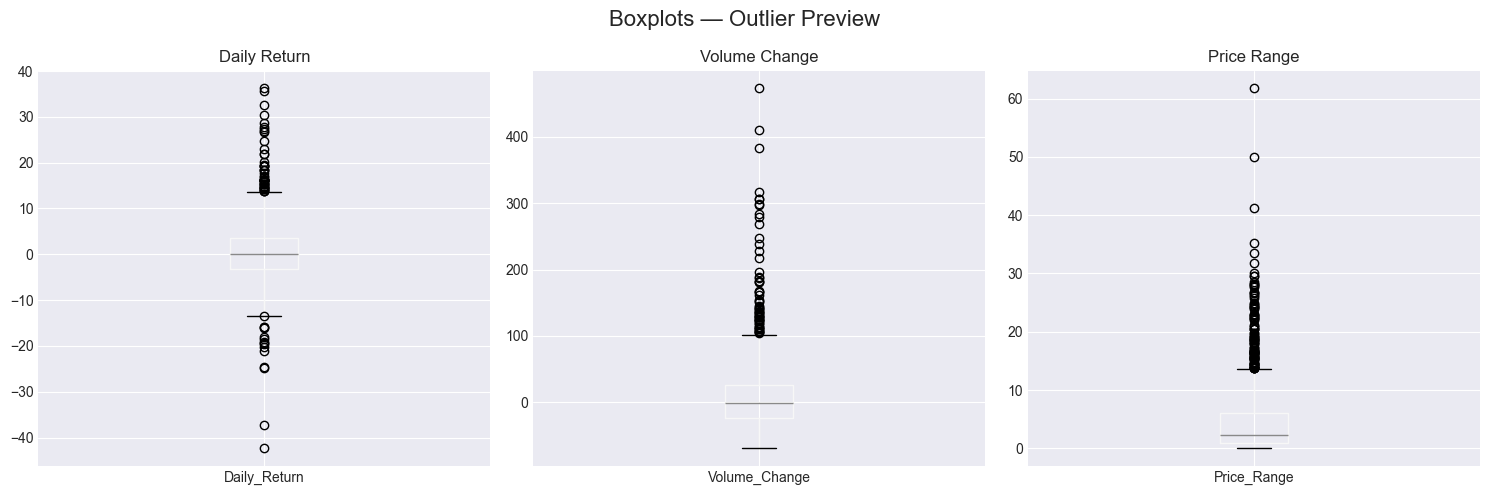

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column='Daily_Return',   ax=axes[0])
axes[0].set_title('Daily Return')

df.boxplot(column='Volume_Change',  ax=axes[1])
axes[1].set_title('Volume Change')

df.boxplot(column='Price_Range',    ax=axes[2])
axes[2].set_title('Price Range')

plt.suptitle('Boxplots — Outlier Preview', fontsize=16)
plt.tight_layout()
plt.savefig('../data/sol_boxplots.png', dpi=150)
plt.show()